In [1]:
import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from toolbox_mingyang import *

f = h5py.File("../data/SimuData.mat", "r")
print(list(f.keys()))

['Image', 'Magnitude', 'Phase']


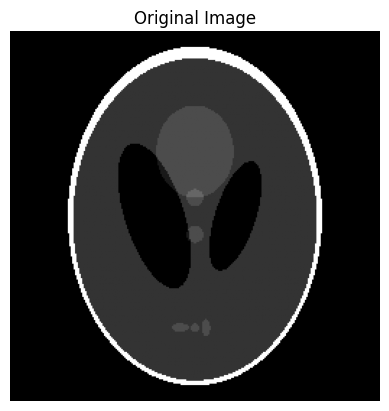

In [2]:
Image = f["Image"][:]
img = Image['real'] + 1j * Image['imag']
show_mri(img[1], "mag", "Original Image")

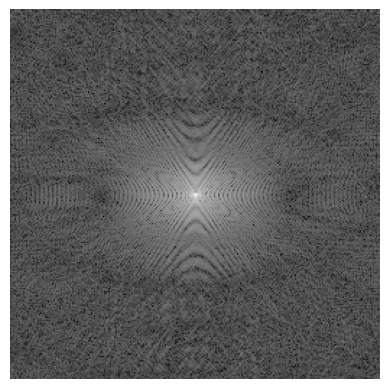

In [3]:
kspace = fft2c_mingyang(img)
show_mri(kspace[2], "kspace")

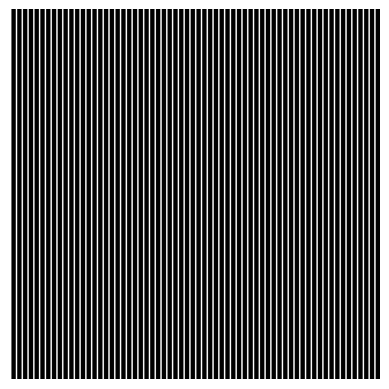

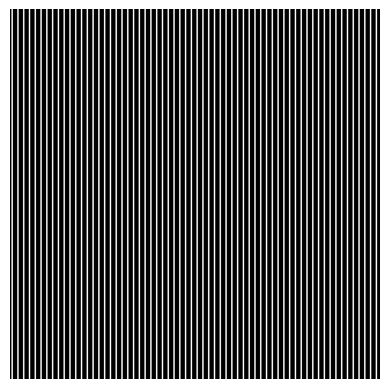

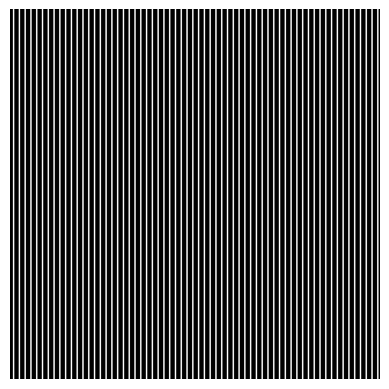

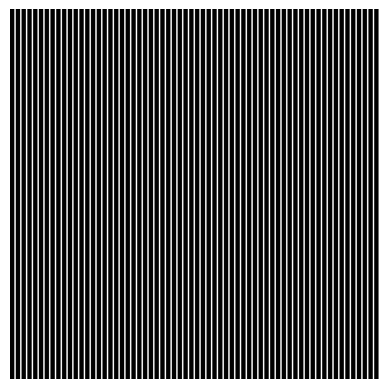

Mask dimension 256 256 4


In [4]:
Nsh, Npe, Nro = kspace.shape
mask = np.zeros((Nsh, Nro, Npe))

for nsh in range(Nsh):
    mask[nsh, nsh::Nsh, :] = 1


show_mri(mask[0], "mag")
show_mri(mask[1], "mag")
show_mri(mask[2], "mag")
show_mri(mask[3], "mag")
print("Mask dimension",Nro, Npe, Nsh)

This is the multi shot undersampling method.

In [5]:
Undersampling_kspace = mask * kspace

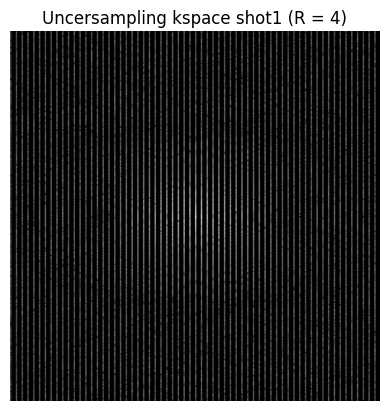

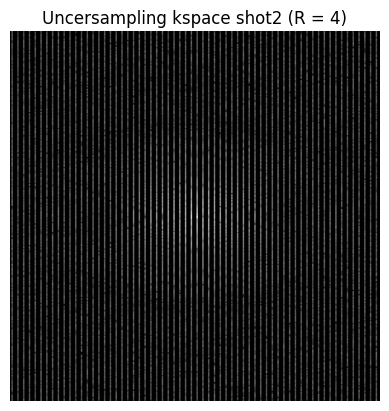

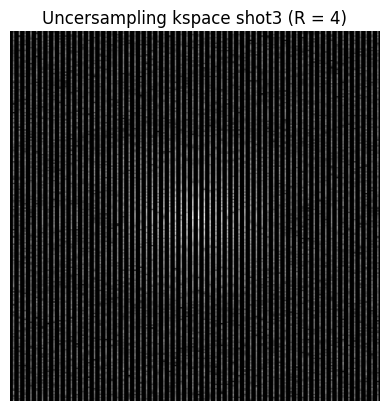

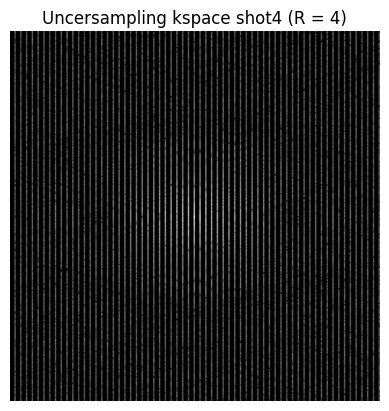

In [6]:
show_mri(Undersampling_kspace[0], "kspace", "Uncersampling kspace shot1 (R = 4)")
show_mri(Undersampling_kspace[1], "kspace", "Uncersampling kspace shot2 (R = 4)")
show_mri(Undersampling_kspace[2], "kspace", "Uncersampling kspace shot3 (R = 4)")
show_mri(Undersampling_kspace[3], "kspace", "Uncersampling kspace shot4 (R = 4)")